# Quantum Support Vector Classification (QSVC) for Colorectal Cancer vs Healthy Gut Microbiome Classification

**A quantum-kernel counterpart to the binary classical ML pipeline (Logistic Regression, SVM, Random Forest, XGBoost)**

Dataset: Zeller et al. (2014) gut microbiome relative-abundance data (`curatedMetagenomicData`)
Task: Binary classification, **Healthy vs CRC** (Adenoma excluded)
Feature set: **Top 8 features**, ranked and selected (training data only) from the 20 Boruta-selected microbial taxa used by the four classical models
Random seed: `SEED = 1910` (project-wide)

> **Important scope note.** The four classical models (Logistic Regression, SVM, Random Forest, XGBoost) were trained on the full 20-feature Boruta-selected space. This QSVC notebook is **not** trained on that same 20-dimensional space. Because exact statevector simulation of a quantum kernel scales exponentially with the number of qubits/features, this notebook further reduces the input to the **top 8 features**, ranked using a training-data-only supervised importance method. Every section below states this explicitly so results are never mis-read as "QSVC vs. classical models on an identical feature space."


## Introduction

Colorectal cancer (CRC) is associated with reproducible shifts in the gut microbiome: enrichment of oral/pathogenic taxa such as *Fusobacterium nucleatum*, *Parvimonas micra*, and *Peptostreptococcus stomatis*, alongside depletion of short-chain-fatty-acid producers such as *Eubacterium rectale* and *Anaerostipes hadrus*. The four classical models in this project (Logistic Regression, SVM, Random Forest, XGBoost) already demonstrated that these microbial relative-abundance signatures separate CRC patients from healthy controls using a shared, leakage-free pipeline: Adenoma exclusion, an 80:20 stratified train/test split, near-zero-variance filtering, Boruta feature selection (20 features retained), and center/scale standardization, all computed from training data only.

This notebook extends that pipeline with a **Quantum Support Vector Classifier (QSVC)**. Rather than defining similarity between two microbiome samples with a classical kernel (e.g. the RBF kernel used by the classical SVM), a QSVC encodes each sample into a quantum state via a parameterized quantum circuit (a *quantum feature map*) and defines the kernel as the fidelity (state overlap) between two such quantum states. This kernel is then handed to an otherwise ordinary support vector machine.

Because exact quantum-kernel simulation is computationally expensive and scales poorly with the number of qubits, this notebook does **not** use all 20 Boruta-selected features. Instead, it ranks those 20 features using a supervised, training-data-only importance method and retains only the **top 8**, which become the 8 qubits of the quantum feature map. The scientific question this notebook answers is therefore: **given the same 92/22 train/test split and the same evaluation metrics used by the classical models, but a computationally feasible 8-feature reduction of the classical models' 20-feature space, does a quantum kernel separate CRC from Healthy samples as well as, better than, or worse than a classical kernel trained on that identical 8-feature representation?**


## Environment compatibility gate

The next code cell checks the exact Python/package versions recorded by the validated QSVC analysis. It intentionally stops rather than installing a newer package automatically.

```python
from importlib import metadata as importlib_metadata
import platform

EXPECTED_PYTHON = "3.14.6"
EXPECTED_PACKAGES = {
    "qiskit": "2.5.1",
    "qiskit-machine-learning": "0.9.0",
    "qiskit-aer": "0.17.2",
    "scikit-learn": "1.9.0",
    "numpy": "2.5.1",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "joblib": "1.5.3",
}

if platform.python_version() != EXPECTED_PYTHON:
    raise RuntimeError(
        f"Validated analysis used Python {EXPECTED_PYTHON}; "
        f"this kernel is {platform.python_version()}. "
        "Create the pinned environment from requirements.txt."
    )

missing_or_mismatched = {}
for package, expected in EXPECTED_PACKAGES.items():
    try:
        actual = importlib_metadata.version(package)
    except importlib_metadata.PackageNotFoundError:
        actual = "NOT INSTALLED"
    if actual != expected:
        missing_or_mismatched[package] = {"expected": expected, "found": actual}

if missing_or_mismatched:
    raise RuntimeError(
        "Validated QSVC environment mismatch. "
        "Install requirements.txt in a clean Python 3.14.6 environment before running."
        f" Details: {missing_or_mismatched}"
    )

print("Environment compatibility gate passed.")
```


## Research Objective

1. Reuse the already-exported, R-derived 20-feature Boruta-selected training (92 samples) and test (22 samples) datasets — the same split, preprocessing, and features used by the four classical models.
2. Rank those 20 features using a supervised, training-data-only importance method and select the **top 8**, which become the QSVC's 8 qubits. This step is required purely for computational feasibility of exact quantum-kernel simulation.
3. Rescale the selected 8 features into a bounded rotation-angle range (`[0, 2π]`) for quantum encoding, fitting the scaler on training data only.
4. Build an 8-qubit `ZZFeatureMap`-based quantum kernel, train a QSVC on the 92-sample training kernel, and evaluate it **exactly once** on the untouched 22-sample test set.
5. Train a classical SVM on the *same* 8-feature, angle-scaled representation as a matched, same-feature-space baseline, so that any QSVC-vs-classical performance gap can be attributed to the kernel (quantum vs. classical) rather than to a difference in feature set.
6. Report every result honestly: this is an 8-feature, single-split, proof-of-concept comparison — not a claim that QSVC matches, exceeds, or is directly comparable to the full 20-feature classical models.


## QSVC Workflow Overview

```
20 Boruta-selected features (already exported from R, training+test)
        │
        ▼
Training-data-only supervised feature ranking (this notebook)
        │
        ▼
Top 8 features selected  ───────────────►  QSVC_Top8_Features.csv
        │
        ▼
MinMax angle scaling → [0, 2π]  (fit on training data only)
        │
        ▼
8-qubit ZZFeatureMap  (reps = 1, entanglement = "linear")
        │
        ▼
FidelityQuantumKernel (statevector simulation, ComputeUncompute)
        │
        ├──► K_train (92 × 92)  ──►  QSVC.fit()
        │
        └──► K_test  (22 × 92)  ──►  QSVC.predict() / decision_function()
                        │
                        ▼
        Healthy vs CRC test-set evaluation (22 held-out samples)
                        │
                        ▼
        Compared against a classical SVM on the SAME 8 features
```

Every arrow above is implemented, in order, in the sections that follow.


## Computational Rationale for Reducing 20 Features to the Top 8

Exact (noiseless, statevector) simulation of a quantum kernel requires one qubit per encoded feature, and the memory/time cost of simulating an *n*-qubit statevector grows as `O(2^n)`. At 20 qubits, a single statevector already holds `2^20 ≈ 1,048,576` complex amplitudes, and the training kernel alone requires on the order of `92 × 91 / 2 ≈ 4,186` pairwise circuit evaluations (plus `22 × 92 = 2,024` for the test kernel). That workload is at the edge of what is practical on a laptop-class machine, especially if it needs to be repeated for hyperparameter tuning or sanity checks.

Reducing the input to **8 features / 8 qubits** cuts the statevector size to `2^8 = 256` amplitudes per circuit — roughly a 4,000-fold reduction in per-circuit memory relative to 20 qubits — while keeping the same number of pairwise kernel evaluations (4,186 + 2,024), making the full pipeline comfortably tractable.

This reduction is a **computational necessity for exact quantum simulation**, not a claim that 8 features are biologically superior to 20. Consequently:

- The four classical models (Logistic Regression, SVM, Random Forest, XGBoost) remain benchmarked on the full 20-feature Boruta-selected space and are **not** re-run here.
- This notebook additionally trains a classical SVM on the *same* 8-feature representation used by the QSVC, so there is at least one same-feature-space classical comparator alongside the original 20-feature classical results.
- Every results table and the final discussion explicitly label which feature count (8 vs. 20) each number refers to.


**Interpretation.** A successful run prints `Package installation complete.` with no `ERROR:` lines above it. If pip reports a dependency conflict, it is almost always caused by a pre-existing, older `qiskit` install in the same environment — the cleanest fix is a fresh virtual environment (`python -m venv` or `conda create`) before re-running this cell.


## Section 2 — Imports, Reproducibility Seed, and Global Configuration

**What this section does.** Imports every library object used later in the notebook, fixes the single project-wide reproducibility seed (`SEED = 1910`, matching every `set.seed(1910)` call in the R pipeline), configures warnings and plotting defaults, and creates the project's output directories.

**Why it is necessary.** Centralizing imports and the seed in one place keeps every later cell free of inline imports and makes the dependency surface of the notebook visible up front, mirroring the `library(...)` block at the top of each R `.Rmd`.

**How it fits into the pipeline.** Every stochastic step later in this notebook (the training-only feature ranking, the classical SVM baseline, and any solver-level randomness in QSVC) references this single `SEED` constant. The quantum kernel itself is computed via exact statevector simulation and is deterministic given fixed inputs, so it needs no separate seeding.


In [1]:
# ==========================================================
# Section 2: Imports
# ==========================================================
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

warnings.filterwarnings("ignore")

print("Imports successful.")

# ==========================================================
# Reproducibility
# ==========================================================
SEED = 1910
import random
random.seed(SEED)
np.random.seed(SEED)
print(f"Project random seed set to: {SEED}")

# ==========================================================
# Quantum-pipeline constants
# ==========================================================
N_QUBITS = 8          # top-8 features == 8 qubits (NOT 20)
FEATURE_REPS = 1
ENTANGLEMENT = "linear"
POSITIVE_CLASS = "CRC"

# ==========================================================
# Plotting defaults
# ==========================================================
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print(f"N_QUBITS = {N_QUBITS}, reps = {FEATURE_REPS}, entanglement = '{ENTANGLEMENT}'")
print(f"Positive class for all metrics: {POSITIVE_CLASS}")

Imports successful.
Project random seed set to: 1910
N_QUBITS = 8, reps = 1, entanglement = 'linear'
Positive class for all metrics: CRC


In [2]:
# ==========================================================
# Section 2 (continued): Project directory setup
# ==========================================================
# This notebook is expected to sit inside the "05 QSVC" project
# folder, alongside a "data/" folder already populated by the R
# export step. Adjust project_root only if you relocate the notebook.
project_root = Path(".")

data_dir    = project_root / "data"
models_dir  = project_root / "models"
results_dir = project_root / "results"
figures_dir = project_root / "figures"

for d in (data_dir, models_dir, results_dir, figures_dir):
    d.mkdir(parents=True, exist_ok=True)

print("data_dir    :", data_dir.resolve())
print("models_dir  :", models_dir.resolve())
print("results_dir :", results_dir.resolve())
print("figures_dir :", figures_dir.resolve())

data_dir    : C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\data
models_dir  : C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models
results_dir : C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results
figures_dir : C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures


**Interpretation.** All four directories (`data/`, `models/`, `results/`, `figures/`) should now exist relative to the notebook's working directory. If `data/` did not already contain `QSVC_Train_Data.csv`, `QSVC_Test_Data.csv`, and `QSVC_Feature_Name_Map.csv` before running this notebook, Section 3 below will fail with a clear `FileNotFoundError` — copy those three files in before continuing.


## Section 3 — Load the Exported Train/Test Data

**What this section does.** Loads the three artifacts already produced by the R export step: the 20-feature, already-standardized training data (92 samples), the matching test data (22 samples), and the feature-name map (syntactic ↔ original taxonomic name).

**Why it is necessary.** This is the single point of contact between the R classical pipeline and this Python notebook. The R side has already performed Adenoma exclusion, the 80:20 stratified split, near-zero-variance filtering, Boruta selection (20 features), and center/scale standardization (fit on training data only) — **none of that is repeated here**.

**How it fits into the pipeline.** Everything downstream (feature ranking, angle scaling, quantum kernel, QSVC) operates on the data loaded in this cell.


In [3]:
# ==========================================================
# Section 3: Load exported R-derived training and test data
# ==========================================================
train_df = pd.read_csv(data_dir / "QSVC_Train_Data.csv")
test_df  = pd.read_csv(data_dir / "QSVC_Test_Data.csv")
feature_name_map = pd.read_csv(data_dir / "QSVC_Feature_Name_Map.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nClass distribution (train):")
print(train_df["disease"].value_counts())
print("\nClass distribution (test):")
print(test_df["disease"].value_counts())

train_df.head()

Train shape: (92, 22)
Test shape : (22, 22)

Class distribution (train):
disease
healthy    49
CRC        43
Name: count, dtype: int64

Class distribution (test):
disease
healthy    12
CRC        10
Name: count, dtype: int64


,SampleID,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Lachnospiraceae.g__Anaerostipes.s__Anaerostipes_hadrus,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Lachnospiraceae.g__Lachnospiraceae_unclassified.s__Eubacterium_rectale,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Eubacteriaceae.g__Eubacterium.s__Eubacterium_hallii,k__Bacteria.p__Bacteroidetes.c__Bacteroidia.o__Bacteroidales.f__Bacteroidaceae.g__Bacteroides.s__Bacteroides_uniformis,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Ruminococcaceae.g__Ruminococcus.s__Ruminococcus_bicirculans,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Oscillospiraceae.g__Oscillibacter.s__Oscillibacter_sp_CAG_241,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Lachnospiraceae.g__Blautia.s__Blautia_wexlerae,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Ruminococcaceae.g__Ruthenibacterium.s__Ruthenibacterium_lactatiformans,k__Bacteria.p__Proteobacteria.c__Deltaproteobacteria.o__Desulfovibrionales.f__Desulfovibrionaceae.g__Bilophila.s__Bilophila_wadsworthia,...,k__Bacteria.p__Proteobacteria.c__Betaproteobacteria.o__Burkholderiales.f__Sutterellaceae.g__Turicimonas.s__Turicimonas_muris,k__Bacteria.p__Firmicutes.c__Tissierellia.o__Tissierellales.f__Peptoniphilaceae.g__Parvimonas.s__Parvimonas_micra,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Ruminococcaceae.g__Flavonifractor.s__Flavonifractor_plautii,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Clostridiaceae.g__Hungatella.s__Hungatella_hathewayi,k__Bacteria.p__Firmicutes.c__Negativicutes.o__Veillonellales.f__Veillonellaceae.g__Dialister.s__Dialister_pneumosintes,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Peptostreptococcaceae.g__Peptostreptococcus.s__Peptostreptococcus_stomatis,k__Bacteria.p__Proteobacteria.c__Deltaproteobacteria.o__Desulfovibrionales.f__Desulfovibrionaceae.g__Desulfovibrio.s__Desulfovibrio_piger,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Clostridiales_Family_XIII_Incertae_Sedis.g__Mogibacterium.s__Mogibacterium_timidum,k__Bacteria.p__Fusobacteria.c__Fusobacteriia.o__Fusobacteriales.f__Fusobacteriaceae.g__Fusobacterium.s__Fusobacterium_nucleatum,disease
0,CCIS00146684ST-4-0,1.050439,0.361081,0.977432,-0.587232,0.261958,-0.174434,-0.326676,-0.312933,0.244551,...,1.666250,-0.138934,-0.254227,-0.223167,-0.280956,-0.188731,-0.179403,-0.31162,-0.202979,healthy
1,CCIS02124300ST-4-0,0.135344,2.029875,-0.216788,-0.834761,-0.439472,-0.210824,-0.351436,-0.426262,0.236104,...,-0.412806,-0.139449,-0.146562,-0.129485,-0.280956,-0.188731,-0.179403,-0.31162,-0.202979,healthy
2,CCIS02379307ST-4-0,-0.520007,1.015075,-0.551264,0.581911,-0.295792,-0.315883,-0.370418,-0.318520,0.398700,...,-0.412806,-0.110416,-0.222145,-0.124623,2.838942,1.244708,-0.179403,-0.31162,-0.202979,CRC
3,CCIS02856720ST-4-0,-0.397756,2.307318,-0.234311,-0.110745,-0.439472,-0.313555,-0.308442,-0.338543,0.361394,...,0.938161,-0.139449,0.006495,-0.223167,-0.280956,-0.188731,-0.083720,-0.31162,-0.202979,healthy
4,CCIS03473770ST-4-0,-0.297039,1.094816,0.925981,-0.140027,-0.004119,-0.285022,-0.220202,-0.457566,0.224930,...,-0.412806,-0.136986,-0.228783,-0.223167,-0.280956,-0.188731,-0.179403,-0.31162,-0.202979,healthy


**Interpretation.** Expect `Train shape: (92, 22)` and `Test shape: (22, 22)` — 20 microbial feature columns plus `SampleID` and `disease`. If either shape does not match, or if a class is missing from either split, **stop here** — do not proceed to feature ranking or modeling until the discrepancy with the R export is resolved. Section 4 turns these expectations into hard assertions.


## Section 4 — Verify Dataset Integrity

**What this section does.** Runs explicit assertions confirming the exported data matches what the classical pipeline produced: 92 training / 22 test samples, exactly two classes (`healthy`, `CRC`), 20 feature columns shared identically between train and test, no missing values, and no duplicate feature columns.

**Why it is necessary.** The rest of the notebook assumes these invariants hold. Failing loudly and early here is far cheaper than debugging a silent mismatch after quantum kernel computation (which is the most expensive step in the notebook).

**How it fits into the pipeline.** This is a gate: if any assertion fails, the notebook stops before touching the quantum pipeline at all.


In [4]:
# ==========================================================
# Section 4: Verify dataset integrity
# ==========================================================
non_feature_cols = {"SampleID", "disease"}
train_feature_cols_20 = [c for c in train_df.columns if c not in non_feature_cols]
test_feature_cols_20  = [c for c in test_df.columns if c not in non_feature_cols]

assert train_df.shape[0] == 92, f"Expected 92 training samples, got {train_df.shape[0]}"
assert test_df.shape[0] == 22, f"Expected 22 test samples, got {test_df.shape[0]}"
assert len(train_feature_cols_20) == 20, f"Expected 20 training features, got {len(train_feature_cols_20)}"
assert len(test_feature_cols_20) == 20, f"Expected 20 test features, got {len(test_feature_cols_20)}"
assert train_feature_cols_20 == test_feature_cols_20, "Train/test feature columns differ or are out of order."
assert set(train_df["disease"].unique()) == {"healthy", "CRC"}, \
    f"Expected classes {{'healthy','CRC'}}, got {set(train_df['disease'].unique())}"
assert set(test_df["disease"].unique()) == {"healthy", "CRC"}, \
    f"Expected classes {{'healthy','CRC'}}, got {set(test_df['disease'].unique())}"
assert train_df[train_feature_cols_20].isnull().sum().sum() == 0, "Missing values found in training features."
assert test_df[test_feature_cols_20].isnull().sum().sum() == 0, "Missing values found in test features."
assert len(train_feature_cols_20) == len(set(train_feature_cols_20)), "Duplicate feature columns in training data."
assert train_df["SampleID"].is_unique, "Duplicate SampleID values in training data."
assert test_df["SampleID"].is_unique, "Duplicate SampleID values in test data."

print("All dataset integrity checks passed:")
print(f"  - Training samples : {train_df.shape[0]} (expected 92)")
print(f"  - Testing samples  : {test_df.shape[0]} (expected 22)")
print(f"  - Feature columns  : {len(train_feature_cols_20)} (expected 20, Boruta-selected)")
print(f"  - Classes          : {sorted(train_df['disease'].unique())}")
print("  - No missing values, no duplicate columns/IDs, train/test columns match.")

All dataset integrity checks passed:
  - Training samples : 92 (expected 92)
  - Testing samples  : 22 (expected 22)
  - Feature columns  : 20 (expected 20, Boruta-selected)
  - Classes          : ['CRC', 'healthy']
  - No missing values, no duplicate columns/IDs, train/test columns match.


**Interpretation.** All six checks passing confirms the Python-side data is byte-for-byte structurally consistent with what the classical R models used, before any feature reduction happens. Any `AssertionError` here points to a mismatch between the R export step and what was copied into `data/` — re-run the R export cell before continuing.


## Section 5 — Separate Metadata, Features, and Labels

**What this section does.** Splits `SampleID` and `disease` off from the 20 microbial feature columns, producing `X_train_20`, `X_test_20` (feature matrices) and `y_train`, `y_test` (encoded labels), with `CRC` explicitly encoded as the positive class (`1`).

**Why it is necessary.** Every downstream step (feature ranking, scaling, kernel computation, model fitting) needs a clean numeric feature matrix — `SampleID` is a string identifier and must never enter the feature matrix, and `disease` must never leak into `X`.

**How it fits into the pipeline.** `X_train_20` / `X_test_20` are the 20-feature starting point for the training-only feature ranking in Section 6.


In [5]:
# ==========================================================
# Section 5: Separate features and labels
# ==========================================================
X_train_20 = train_df[train_feature_cols_20].copy()
X_test_20  = test_df[test_feature_cols_20].copy()

label_encoder = LabelEncoder()
label_encoder.fit(["healthy", "CRC"])  # fixed, explicit ordering
# Force CRC -> 1, healthy -> 0 regardless of alphabetical LabelEncoder default
class_to_int = {"healthy": 0, "CRC": 1}
y_train = train_df["disease"].map(class_to_int).to_numpy()
y_test  = test_df["disease"].map(class_to_int).to_numpy()

assert not np.isnan(y_train).any() and not np.isnan(y_test).any(), "Unmapped disease label found."

print("Label encoding: healthy = 0, CRC = 1 (CRC is the positive class for all metrics)")
print("X_train_20 shape:", X_train_20.shape)
print("X_test_20 shape :", X_test_20.shape)
print("y_train class balance:", dict(zip(*np.unique(y_train, return_counts=True))))
print("y_test class balance :", dict(zip(*np.unique(y_test, return_counts=True))))

Label encoding: healthy = 0, CRC = 1 (CRC is the positive class for all metrics)
X_train_20 shape: (92, 20)
X_test_20 shape : (22, 20)
y_train class balance: {np.int64(0): np.int64(49), np.int64(1): np.int64(43)}
y_test class balance : {np.int64(0): np.int64(12), np.int64(1): np.int64(10)}


## Section 6 — Rank the 20 Features Using Training Data Only, Select the Top 8

**What this section does.** Fits a `RandomForestClassifier` **on the training data only** (`X_train_20`, `y_train`), ranks the 20 already-Boruta-selected features by Gini importance, and keeps the top 8.

**Why it is necessary.** The 20 features were already selected using training data only (Boruta, in R). This second, quantum-motivated reduction from 20 → 8 must **also** be training-data-only, or the QSVC's test-set evaluation would be contaminated by information about which features happen to separate the classes in the test set. Random Forest importance is used because it is a well-established, deterministic-given-a-seed, model-agnostic ranking method that does not require an additional distributional assumption.

**How it fits into the pipeline.** The resulting 8 feature names become `N_QUBITS = 8` — one feature per qubit in the quantum feature map built in Section 9.


In [6]:
# ==========================================================
# Section 6: Rank the 20 features (training data only) and select top 8
# ==========================================================
ranking_model = RandomForestClassifier(
    n_estimators=1000,
    random_state=SEED,
    n_jobs=-1
)
ranking_model.fit(X_train_20, y_train)  # TRAINING DATA ONLY -- no test-set involvement

importances = pd.Series(ranking_model.feature_importances_, index=X_train_20.columns)
feature_ranking = importances.sort_values(ascending=False).rename("Importance").reset_index()
feature_ranking.columns = ["Syntactic_Feature", "Importance"]
feature_ranking.insert(0, "Rank", np.arange(1, len(feature_ranking) + 1))

TOP_K = 8
top8_features = feature_ranking.head(TOP_K)["Syntactic_Feature"].tolist()

assert len(top8_features) == 8, f"Expected exactly 8 features, got {len(top8_features)}"
assert len(set(top8_features)) == 8, "Duplicate feature names selected."
assert all(f in X_train_20.columns for f in top8_features), "A selected feature is missing from training data."
assert all(f in X_test_20.columns for f in top8_features), "A selected feature is missing from test data."

print("Feature ranking (training data only), full 20-feature list:")
print(feature_ranking.to_string(index=False))
print(f"\nTop {TOP_K} features selected for the QSVC (8 qubits):")
for f in top8_features:
    print(" -", f)

Feature ranking (training data only), full 20-feature list:
 Rank                                                                                                                              Syntactic_Feature  Importance
    1         k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Peptostreptococcaceae.g__Peptostreptococcus.s__Peptostreptococcus_stomatis    0.094109
    2                       k__Bacteria.p__Firmicutes.c__Bacilli.o__Lactobacillales.f__Streptococcaceae.g__Streptococcus.s__Streptococcus_salivarius    0.083404
    3                              k__Bacteria.p__Firmicutes.c__Tissierellia.o__Tissierellales.f__Peptoniphilaceae.g__Parvimonas.s__Parvimonas_micra    0.059185
    4             k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Ruminococcaceae.g__Ruthenibacterium.s__Ruthenibacterium_lactatiformans    0.056907
    5                             k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Lachnospiraceae.g__Anaerostipes.s__Anaero

**Interpretation.** The printed table ranks all 20 Boruta-selected features by training-only Random Forest importance; the top 8 rows are the features that become the QSVC's 8 qubits. Because `X_test_20` and `y_test` were never passed to `ranking_model.fit()`, this ranking cannot be inflated by test-set information — it is exactly as leakage-free as the Boruta step that produced the original 20.


In [7]:
# ==========================================================
# Section 6 (continued): Save the Top 8 feature list
# ==========================================================
top8_features_df = feature_ranking.head(TOP_K).copy()
top8_features_df.to_csv(data_dir / "QSVC_Top8_Features.csv", index=False)
top8_features_df.to_csv(results_dir / "QSVC_Selected_Top8_Features.csv", index=False)

print("Saved:", (data_dir / "QSVC_Top8_Features.csv").resolve())
print("Saved:", (results_dir / "QSVC_Selected_Top8_Features.csv").resolve())
top8_features_df

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\data\QSVC_Top8_Features.csv
Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_Selected_Top8_Features.csv


,Rank,Syntactic_Feature,Importance
0,1,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clo...,0.094109
1,2,k__Bacteria.p__Firmicutes.c__Bacilli.o__Lactob...,0.083404
2,3,k__Bacteria.p__Firmicutes.c__Tissierellia.o__T...,0.059185
3,4,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clo...,0.056907
4,5,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clo...,0.056322
5,6,k__Bacteria.p__Proteobacteria.c__Deltaproteoba...,0.056063
6,7,k__Bacteria.p__Bacteroidetes.c__Bacteroidia.o_...,0.054109
7,8,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clo...,0.051814


## Section 7 — Map the Top 8 Features to Their Original Taxonomic Names

**What this section does.** Joins the top-8 syntactic feature names against `QSVC_Feature_Name_Map.csv` (already exported from R) to recover the original microbial taxonomic strings, producing a biologically interpretable table.

**Why it is necessary.** `QSVC` never sees or reports feature importance in a classically interpretable way (Section 21 discusses this explicitly), so this table is the primary place where the notebook connects the quantum model's 8 input dimensions back to actual microbial taxa for a reader of the manuscript.

**How it fits into the pipeline.** This table is saved to `results/` and referenced again in the final interpretation (Section 25).


In [8]:
# ==========================================================
# Section 7: Map Top 8 features to original taxonomic names
# ==========================================================
# Be robust to whichever column layout QSVC_Feature_Name_Map.csv uses.
map_cols_lower = {c.lower(): c for c in feature_name_map.columns}
syntactic_col = map_cols_lower.get("syntactic", list(feature_name_map.columns)[1]
                                    if len(feature_name_map.columns) > 1 else feature_name_map.columns[0])
original_col  = map_cols_lower.get("original", list(feature_name_map.columns)[0])

top8_interpretation = top8_features_df.merge(
    feature_name_map[[syntactic_col, original_col]],
    left_on="Syntactic_Feature", right_on=syntactic_col, how="left"
).drop(columns=[syntactic_col])
top8_interpretation = top8_interpretation.rename(columns={original_col: "Original_Taxonomic_Name"})
top8_interpretation = top8_interpretation[["Rank", "Syntactic_Feature", "Original_Taxonomic_Name", "Importance"]]

assert top8_interpretation["Original_Taxonomic_Name"].notnull().all(), \
    "One or more Top-8 features could not be mapped to an original taxonomic name -- check QSVC_Feature_Name_Map.csv."

top8_interpretation.to_csv(results_dir / "QSVC_Top8_Feature_Interpretation.csv", index=False)
print("Saved:", (results_dir / "QSVC_Top8_Feature_Interpretation.csv").resolve())
top8_interpretation

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_Top8_Feature_Interpretation.csv


,Rank,Syntactic_Feature,Original_Taxonomic_Name,Importance
0,1,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clo...,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,0.094109
1,2,k__Bacteria.p__Firmicutes.c__Bacilli.o__Lactob...,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,0.083404
2,3,k__Bacteria.p__Firmicutes.c__Tissierellia.o__T...,k__Bacteria|p__Firmicutes|c__Tissierellia|o__T...,0.059185
3,4,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clo...,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,0.056907
4,5,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clo...,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,0.056322
5,6,k__Bacteria.p__Proteobacteria.c__Deltaproteoba...,k__Bacteria|p__Proteobacteria|c__Deltaproteoba...,0.056063
6,7,k__Bacteria.p__Bacteroidetes.c__Bacteroidia.o_...,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,0.054109
7,8,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clo...,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,0.051814


**Interpretation.** Each of the 8 rows above pairs a QSVC input dimension (one qubit) with its biological identity and its training-only importance rank. Report this table alongside the QSVC results in any write-up — it is the closest this notebook gets to "feature importance" for a kernel method that does not natively provide one.


## Section 8 — Subset Train/Test Data to the Top 8 Features

**What this section does.** Creates `X_train_8` and `X_test_8`, the 8-column feature matrices that feed the rest of the notebook, subsetting strictly by the `top8_features` list determined in Section 6.

**Why it is necessary.** All quantum-pipeline steps from here on (angle scaling, feature map, kernel, QSVC, and the matched classical SVM baseline) must operate on exactly these 8 columns, in a fixed, explicit order.

**How it fits into the pipeline.** `X_train_8.shape == (92, 8)` and `X_test_8.shape == (22, 8)` are the shapes every later shape-assertion checks against.


In [9]:
# ==========================================================
# Section 8: Subset to the Top 8 features
# ==========================================================
X_train_8 = X_train_20[top8_features].copy()
X_test_8  = X_test_20[top8_features].copy()

assert X_train_8.shape == (92, 8), f"Unexpected X_train_8 shape: {X_train_8.shape}"
assert X_test_8.shape == (22, 8), f"Unexpected X_test_8 shape: {X_test_8.shape}"
assert list(X_train_8.columns) == list(X_test_8.columns) == top8_features, "Column order mismatch."

print("X_train_8 shape:", X_train_8.shape, " (expected (92, 8))")
print("X_test_8 shape :", X_test_8.shape, " (expected (22, 8))")
X_train_8.head()

X_train_8 shape: (92, 8)  (expected (92, 8))
X_test_8 shape : (22, 8)  (expected (22, 8))


,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Peptostreptococcaceae.g__Peptostreptococcus.s__Peptostreptococcus_stomatis,k__Bacteria.p__Firmicutes.c__Bacilli.o__Lactobacillales.f__Streptococcaceae.g__Streptococcus.s__Streptococcus_salivarius,k__Bacteria.p__Firmicutes.c__Tissierellia.o__Tissierellales.f__Peptoniphilaceae.g__Parvimonas.s__Parvimonas_micra,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Ruminococcaceae.g__Ruthenibacterium.s__Ruthenibacterium_lactatiformans,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Lachnospiraceae.g__Anaerostipes.s__Anaerostipes_hadrus,k__Bacteria.p__Proteobacteria.c__Deltaproteobacteria.o__Desulfovibrionales.f__Desulfovibrionaceae.g__Bilophila.s__Bilophila_wadsworthia,k__Bacteria.p__Bacteroidetes.c__Bacteroidia.o__Bacteroidales.f__Bacteroidaceae.g__Bacteroides.s__Bacteroides_uniformis,k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Oscillospiraceae.g__Oscillibacter.s__Oscillibacter_sp_CAG_241
0,-0.188731,-0.291479,-0.138934,-0.312933,1.050439,0.244551,-0.587232,-0.174434
1,-0.188731,0.000608,-0.139449,-0.426262,0.135344,0.236104,-0.834761,-0.210824
2,1.244708,-0.321714,-0.110416,-0.318520,-0.520007,0.398700,0.581911,-0.315883
3,-0.188731,-0.267361,-0.139449,-0.338543,-0.397756,0.361394,-0.110745,-0.313555
4,-0.188731,0.746523,-0.136986,-0.457566,-0.297039,0.224930,-0.140027,-0.285022


## Section 9 — Quantum-Specific Angle Scaling (Training Data Only)

**What this section does.** Fits a `MinMaxScaler(feature_range=(0, 2*np.pi))` on `X_train_8` **only**, then transforms both `X_train_8` and `X_test_8` with that single fitted scaler.

**Why it is necessary.** The 8 features arriving here are already centered/scaled (standardized in R, fit on training data only) — this step is **not** a repeat of that standardization. It exists purely because the `ZZFeatureMap` uses each feature value as a rotation-gate *angle*, and rotation angles are naturally interpreted on a bounded `[0, 2π]` range. Fitting the `MinMaxScaler` on training data only, then applying it unchanged to the test data, prevents test-set information (its min/max) from leaking into how any sample — train or test — is encoded.

**How it fits into the pipeline.** `X_train_angle` and `X_test_angle` are the exact arrays passed into the `ZZFeatureMap`-based quantum kernel in Section 11 onward.


In [10]:
# ==========================================================
# Section 9: Angle scaling for quantum feature encoding
# ==========================================================
angle_scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
angle_scaler.fit(X_train_8)  # TRAINING DATA ONLY

X_train_angle = angle_scaler.transform(X_train_8)
X_test_angle  = angle_scaler.transform(X_test_8)

print("Angle-scaled training data range: "
      f"[{X_train_angle.min():.4f}, {X_train_angle.max():.4f}]  (target: [0, {2*np.pi:.4f}])")
print("Angle-scaled test data range    : "
      f"[{X_test_angle.min():.4f}, {X_test_angle.max():.4f}]")
print("\nNote: the test range may fall slightly outside [0, 2*pi] if a test sample's raw "
      "value exceeds the training min/max for that feature -- this is expected and correct "
      "behaviour for a scaler fit on training data only (it is NOT re-fit on test data).")

Angle-scaled training data range: [0.0000, 6.2832]  (target: [0, 6.2832])
Angle-scaled test data range    : [0.0000, 10.8451]

Note: the test range may fall slightly outside [0, 2*pi] if a test sample's raw value exceeds the training min/max for that feature -- this is expected and correct behaviour for a scaler fit on training data only (it is NOT re-fit on test data).


**Interpretation.** The training range should sit exactly at `[0.0000, 6.2832]` by construction (MinMaxScaler always maps the fitting data to exactly the target range). The test range may extend slightly outside `[0, 2π]` if any test sample's raw 8-feature value falls outside the training distribution for that feature — this is the correct, expected, and leakage-free behavior of fitting on training data only.


## Section 10 — Classical SVM Baseline on the Same 8 Features

**What this section does.** Trains a standard `sklearn.svm.SVC` (RBF kernel) on the same angle-scaled, 8-feature training representation used by the QSVC (`X_train_angle`, `y_train`), then evaluates it once on `X_test_angle`.

**Why it is necessary.** This is **not** a replacement for the project's four primary classical baselines (which use the full 20-feature space and are reported separately). It exists so the QSVC has at least one classical comparator trained on the *exact same* 8-dimensional input it sees, isolating the effect of the kernel (quantum vs. classical) from the effect of the feature-set reduction.

**How it fits into the pipeline.** Its metrics are recomputed identically to the QSVC's in Section 18 and compared directly in Section 19.


In [11]:
# ==========================================================
# Section 10: Classical SVM baseline (same 8-feature representation)
# ==========================================================
classical_svm = SVC(kernel="rbf", probability=False, random_state=SEED)
classical_svm.fit(X_train_angle, y_train)

y_pred_svm = classical_svm.predict(X_test_angle)
y_score_svm = classical_svm.decision_function(X_test_angle)

def compute_binary_metrics(y_true, y_pred, y_score, positive_label=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Recall_Sensitivity": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Specificity": specificity,
        "F1_Score": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score),
    }

svm_metrics = compute_binary_metrics(y_test, y_pred_svm, y_score_svm)
print("Classical SVM baseline (8 angle-scaled features), test-set metrics:")
for k, v in svm_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

Classical SVM baseline (8 angle-scaled features), test-set metrics:
  Accuracy            : 0.5909
  Precision           : 0.5714
  Recall_Sensitivity  : 0.4000
  Specificity         : 0.7500
  F1_Score            : 0.4706
  ROC_AUC             : 0.6000


**Interpretation.** These metrics describe a classical RBF-kernel SVM operating on the identical 8-dimensional, identically-scaled representation the QSVC will use — this is the fairest possible same-feature-space classical comparator available in this notebook. It is intentionally **not** compared to the original 20-feature classical SVM reported elsewhere in the project, since that would confound the feature-set difference with the kernel difference.


## Section 10A — Logistic Regression Baseline on the Same 8 Features

**What this section does.** Trains a classical binary Logistic Regression model using the same eight Top-Boruta-ranked microbial features and the same 92/22 train-test split used by the QSVC.

**Why it is necessary.** The primary Logistic Regression model in the classical pipeline uses all 20 Boruta-selected features. That model is therefore not a strictly feature-matched comparator for the 8-feature QSVC. This additional Logistic Regression model provides a controlled comparison using the same eight features and the same held-out samples.

**Preprocessing note.** Logistic Regression uses the R-exported standardized 8-feature representation (`X_train_8`, `X_test_8`). The quantum-specific `[0, 2π]` angle transformation is not applied to Logistic Regression because that transformation is used specifically for quantum rotation-angle encoding.

**Important scope.** This is a secondary, feature-matched comparator for QSVC. It does not replace the primary 20-feature Logistic Regression result reported in the classical machine-learning analysis.

In [12]:
# ==========================================================
# Section 10A: Logistic Regression baseline (same 8 features)
# ==========================================================

from sklearn.linear_model import LogisticRegression

logistic_regression_8 = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

logistic_regression_8.fit(
    X_train_8,
    y_train
)

y_pred_lr_8 = logistic_regression_8.predict(
    X_test_8
)

y_score_lr_8 = logistic_regression_8.predict_proba(
    X_test_8
)[:, 1]

lr_8_metrics = compute_binary_metrics(
    y_test,
    y_pred_lr_8,
    y_score_lr_8
)

print(
    "Logistic Regression baseline "
    "(same 8 features), test-set metrics:"
)

for k, v in lr_8_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

Logistic Regression baseline (same 8 features), test-set metrics:
  Accuracy            : 0.6364
  Precision           : 0.6667
  Recall_Sensitivity  : 0.4000
  Specificity         : 0.8333
  F1_Score            : 0.5000
  ROC_AUC             : 0.7083


In [13]:
# ==========================================================
# Save matched 8-feature Logistic Regression results
# ==========================================================

lr_8_metrics_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (same 8 features)",
        **lr_8_metrics
    }
])

lr_8_metrics_df.to_csv(
    results_dir / "QSVC_LogisticRegression_8Feature_Metrics.csv",
    index=False
)

lr_8_predictions_df = pd.DataFrame({
    "SampleID": test_df["SampleID"],
    "Actual_Label": y_test,
    "Predicted_Label": y_pred_lr_8,
    "Probability_CRC": y_score_lr_8
})

lr_8_predictions_df.to_csv(
    results_dir / "QSVC_LogisticRegression_8Feature_Predictions.csv",
    index=False
)

print(
    "Saved:",
    (results_dir / "QSVC_LogisticRegression_8Feature_Metrics.csv").resolve()
)

print(
    "Saved:",
    (results_dir / "QSVC_LogisticRegression_8Feature_Predictions.csv").resolve()
)

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_LogisticRegression_8Feature_Metrics.csv
Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_LogisticRegression_8Feature_Predictions.csv


## Section 11 — Quantum Feature Map (8 Qubits)

**What this section does.** Builds an 8-qubit `ZZFeatureMap` with `reps=1` and `entanglement="linear"`, matching `N_QUBITS = 8` set in Section 2, and visualizes/saves the resulting circuit diagram.

**Why it is necessary.** The feature map is the parameterized quantum circuit that encodes each classical, angle-scaled 8-feature sample into a quantum state. One feature maps to one qubit's rotation angle; the `ZZ`-entangling gates additionally encode pairwise products of features, letting the resulting kernel capture non-linear feature interactions the way an RBF kernel or a tree ensemble can, but through quantum interference rather than a Gaussian distance or a tree split.

**How it fits into the pipeline.** This feature map object is wrapped by `FidelityQuantumKernel` in Section 12 — the feature map itself performs no classification; it only defines *how* two samples are compared.


In [14]:
# ==========================================================
# Section 11: 8-qubit ZZFeatureMap
# ==========================================================
feature_map = ZZFeatureMap(
    feature_dimension=N_QUBITS,   # 8, NOT 20
    reps=FEATURE_REPS,            # 1
    entanglement=ENTANGLEMENT     # "linear"
)

print(f"Feature map: {N_QUBITS} qubits, reps={FEATURE_REPS}, entanglement='{ENTANGLEMENT}'")
print(f"Number of trainable/input parameters: {feature_map.num_parameters} (== number of features, 8)")

fig = feature_map.decompose().draw(output="mpl", style="clifford")
fig.savefig(figures_dir / "QSVC_Feature_Map.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Save feature-map metadata for reproducibility
feature_map_metadata = {
    "n_qubits": N_QUBITS,
    "reps": FEATURE_REPS,
    "entanglement": ENTANGLEMENT,
    "num_parameters": int(feature_map.num_parameters),
    "selected_features_syntactic": top8_features,
}
with open(results_dir / "QSVC_FeatureMap_Metadata.json", "w") as f:
    json.dump(feature_map_metadata, f, indent=2)

print("Saved figure :", (figures_dir / "QSVC_Feature_Map.png").resolve())
print("Saved metadata:", (results_dir / "QSVC_FeatureMap_Metadata.json").resolve())

Feature map: 8 qubits, reps=1, entanglement='linear'
Number of trainable/input parameters: 8 (== number of features, 8)
Saved figure : C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures\QSVC_Feature_Map.png
Saved metadata: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_FeatureMap_Metadata.json


**Interpretation.** The saved circuit diagram shows 8 qubit wires (`q_0`–`q_7`), one Hadamard + `P`-rotation layer per qubit encoding each feature's angle-scaled value, and a linear chain of `ZZ`-entangling gates connecting adjacent qubits. `num_parameters` should print `8`, confirming the feature map expects exactly one input value per qubit — never 20.


## Section 12 — Quantum Kernel Construction

**What this section does.** Wraps the 8-qubit feature map in a `FidelityQuantumKernel`, using `ComputeUncompute` together with a `StatevectorSampler` to compute the fidelity (squared state overlap) between pairs of encoded samples.

**Why it is necessary.** `FidelityQuantumKernel` is what turns the feature map into a scikit-learn-compatible kernel function, `K(x, x') = |⟨φ(x)|φ(x')⟩|²`. Using `StatevectorSampler` performs **exact, noiseless classical simulation** of the quantum circuits — this notebook never claims results were obtained from real quantum hardware.

**How it fits into the pipeline.** The `quantum_kernel` object built here is passed directly to `QSVC(quantum_kernel=...)` in Section 15, and is also used to compute the explicit `K_train` / `K_test` matrices in Sections 13–14 for validation and visualization.


In [15]:
# ==========================================================
# Section 12: Quantum kernel (exact classical simulation, no hardware)
# ==========================================================
sampler = StatevectorSampler(seed=SEED)
fidelity = ComputeUncompute(sampler=sampler)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

print("Quantum kernel constructed: FidelityQuantumKernel over an 8-qubit ZZFeatureMap.")
print("Simulation backend: StatevectorSampler (exact, noiseless classical simulation).")
print("This is a CLASSICAL SIMULATION of a quantum machine-learning model, not a hardware experiment.")

Quantum kernel constructed: FidelityQuantumKernel over an 8-qubit ZZFeatureMap.
Simulation backend: StatevectorSampler (exact, noiseless classical simulation).
This is a CLASSICAL SIMULATION of a quantum machine-learning model, not a hardware experiment.


## Section 13 — Compute the Training Quantum Kernel Matrix

**What this section does.** Evaluates the quantum kernel over every pair of the 92 angle-scaled training samples, producing `K_train`, a `(92, 92)` matrix, and times the computation.

**Why it is necessary.** `K_train[i, j]` represents the quantum-fidelity similarity between training samples *i* and *j* — this matrix, not the raw feature vectors, is what `QSVC` actually optimizes over (precisely analogous to how a classical RBF-kernel SVM operates on a Gram matrix, not raw features, under the hood).

**How it fits into the pipeline.** `K_train` is validated in this section and visualized in Section 14, then implicitly used again when `QSVC.fit()` is called with `X_train_angle` in Section 15 (scikit-learn/Qiskit ML recomputes it internally at fit time using the same `quantum_kernel` object).


In [16]:
# ==========================================================
# Section 13: Training kernel matrix (92 x 92)
# ==========================================================
t0 = time.time()
K_train = quantum_kernel.evaluate(x_vec=X_train_angle)
train_kernel_time = time.time() - t0

print(f"K_train shape: {K_train.shape}  (expected (92, 92))")
print(f"K_train computation time: {train_kernel_time:.2f} seconds")
print(f"K_train diagonal range: [{np.diag(K_train).min():.6f}, {np.diag(K_train).max():.6f}]  (expected ~1.0)")

# ---- Validation ----
assert K_train.shape == (92, 92), f"Unexpected K_train shape: {K_train.shape}"
assert not np.isnan(K_train).any(), "NaN values found in K_train."
assert not np.isinf(K_train).any(), "Infinite values found in K_train."
assert np.allclose(K_train, K_train.T, atol=1e-6), "K_train is not symmetric within tolerance."
assert np.allclose(np.diag(K_train), 1.0, atol=1e-3), "K_train diagonal is not approximately 1."

print("\nAll K_train validation checks passed: correct shape, no NaN/Inf, symmetric, unit diagonal.")

K_train shape: (92, 92)  (expected (92, 92))
K_train computation time: 73.84 seconds
K_train diagonal range: [1.000000, 1.000000]  (expected ~1.0)

All K_train validation checks passed: correct shape, no NaN/Inf, symmetric, unit diagonal.


**Interpretation.** A quantum kernel matrix is a similarity/Gram matrix, exactly like the Gram matrix implicit in a classical RBF-kernel SVM: entries near `1.0` mean two samples' quantum-encoded states are nearly identical, entries near `0.0` mean they are nearly orthogonal. The diagonal is `~1.0` by construction (every sample is maximally similar to itself). Symmetry and the absence of `NaN`/`Inf` are basic sanity checks that catch simulator misconfiguration before any modeling happens.


## Section 14 — Visualize the Training Kernel Matrix

**What this section does.** Renders `K_train` as a heatmap and saves it at publication quality (300 dpi).

**Why it is necessary.** A visual check can reveal structure (e.g. a block pattern separating the two classes) or the absence of structure (a near-uniform matrix, which would suggest the quantum kernel is not discriminating between samples) far more quickly than inspecting raw numbers.

**How it fits into the pipeline.** This is a diagnostic step only — no modeling decision is made from the heatmap itself.


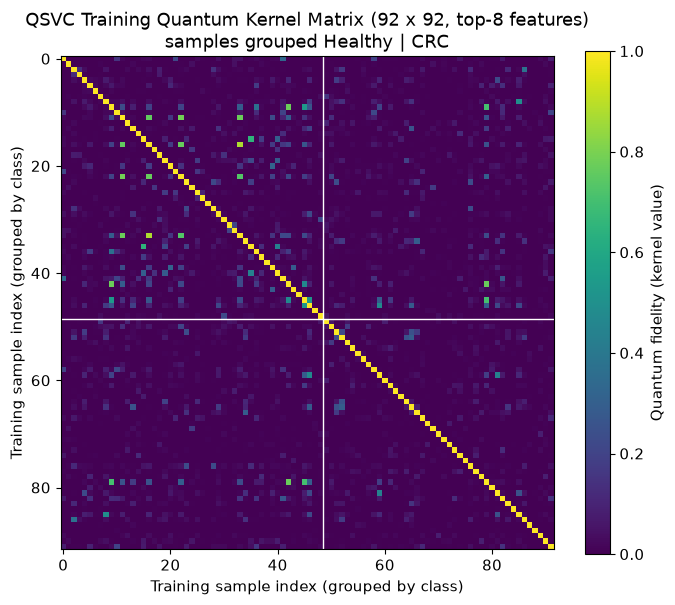

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures\QSVC_Training_Kernel_Matrix.png


In [17]:
# ==========================================================
# Section 14: Visualize K_train
# ==========================================================
order = np.argsort(y_train)  # group Healthy then CRC for visual structure
K_train_ordered = K_train[np.ix_(order, order)]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(K_train_ordered, cmap="viridis", vmin=0, vmax=1)
ax.set_title("QSVC Training Quantum Kernel Matrix (92 x 92, top-8 features)\nsamples grouped Healthy | CRC")
ax.set_xlabel("Training sample index (grouped by class)")
ax.set_ylabel("Training sample index (grouped by class)")
n_healthy = int((y_train == 0).sum())
ax.axhline(n_healthy - 0.5, color="white", linewidth=1)
ax.axvline(n_healthy - 0.5, color="white", linewidth=1)
fig.colorbar(im, ax=ax, label="Quantum fidelity (kernel value)")
fig.tight_layout()
fig.savefig(figures_dir / "QSVC_Training_Kernel_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", (figures_dir / "QSVC_Training_Kernel_Matrix.png").resolve())

**Interpretation.** The white lines mark the boundary between the Healthy block (top-left) and the CRC block (bottom-right). If the two diagonal blocks appear visually brighter/more similar within-class than the off-diagonal (cross-class) blocks, that is a qualitative sign the quantum kernel is picking up class-relevant structure — but this heatmap alone does **not** establish predictive accuracy; that is determined only by the held-out test-set evaluation in Section 18.


## Section 15 — Train QSVC

**What this section does.** Instantiates `QSVC(quantum_kernel=quantum_kernel)` and fits it on the angle-scaled training data (`X_train_angle`, `y_train`) only, timing the fit.

**Why it is necessary.** This is the actual model-fitting step: QSVC wraps a standard SVM solver around the quantum kernel computed in Sections 12–13. The test set is not touched anywhere in this cell.

**How it fits into the pipeline.** The fitted `qsvc` object is used for prediction in Section 16 and saved to disk in Section 22.


In [18]:
# ==========================================================
# Section 15: Train QSVC
# ==========================================================
qsvc = QSVC(quantum_kernel=quantum_kernel)

t0 = time.time()
qsvc.fit(X_train_angle, y_train)
qsvc_train_time = time.time() - t0

print(f"QSVC training complete in {qsvc_train_time:.2f} seconds.")
print(f"Number of support vectors: {qsvc.n_support_ if hasattr(qsvc, 'n_support_') else 'n/a'}")

QSVC training complete in 72.62 seconds.
Number of support vectors: [47 43]


## Section 16 — Generate Predictions on the Held-Out Test Set

**What this section does.** Uses the fitted `qsvc` to predict class labels for the 22 held-out test samples, and separately obtains continuous decision scores via `decision_function()` for ROC-AUC (QSVC does not expose calibrated `predict_proba()` probabilities by default).

**Why it is necessary.** This is the **only** point in the notebook where the test set is used with a fitted model — everything before this cell (feature ranking, angle scaling, kernel construction, QSVC fitting) used training data only.

**How it fits into the pipeline.** `y_pred_qsvc` and `y_score_qsvc` feed every metric computed in Section 18 onward.


In [19]:
# ==========================================================
# Section 16: Predict on the held-out test set
# ==========================================================
t0 = time.time()
y_pred_qsvc = qsvc.predict(X_test_angle)
qsvc_predict_time = time.time() - t0

# QSVC (built on sklearn's SVC under the hood) exposes decision_function,
# NOT calibrated predict_proba, by default -- use decision scores for ROC-AUC
# and state explicitly that these are decision scores, not probabilities.
y_score_qsvc = qsvc.decision_function(X_test_angle)

print(f"Prediction complete in {qsvc_predict_time:.4f} seconds.")
print("Predicted labels (0=healthy, 1=CRC):", y_pred_qsvc)
print("\nNOTE: y_score_qsvc are SVM decision-function scores, not calibrated class")
print("probabilities. ROC-AUC is threshold-independent and valid either way, but")
print("these scores should not be reported or interpreted as probabilities.")

Prediction complete in 35.1613 seconds.
Predicted labels (0=healthy, 1=CRC): [0 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 1 0]

NOTE: y_score_qsvc are SVM decision-function scores, not calibrated class
probabilities. ROC-AUC is threshold-independent and valid either way, but
these scores should not be reported or interpreted as probabilities.


## Section 17 — QSVC Evaluation Metrics

**What this section does.** Computes Accuracy, Precision, Recall/Sensitivity, Specificity, F1-score, and ROC-AUC on the 22-sample test set, with `CRC` fixed as the positive class throughout (consistent with the classical models), and saves a clean results table.

**Why it is necessary.** This is the notebook's primary reported result: how well an 8-feature quantum kernel classifies the held-out samples.

**How it fits into the pipeline.** These metrics are compared directly against the classical SVM baseline (Section 10) in Section 19, and are one of the artifacts referenced in the final interpretation.


In [20]:
# ==========================================================
# Section 17: QSVC test-set metrics
# ==========================================================

from sklearn.metrics import matthews_corrcoef

# Calculate the existing binary classification metrics
qsvc_metrics = compute_binary_metrics(
    y_test,
    y_pred_qsvc,
    y_score_qsvc
)

# Add Matthews correlation coefficient
qsvc_metrics["MCC"] = matthews_corrcoef(
    y_test,
    y_pred_qsvc
)

print("QSVC test-set metrics (positive class = CRC):")

for k, v in qsvc_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

# Save all QSVC test metrics
qsvc_metrics_df = pd.DataFrame([
    {
        "Model": "QSVC (8 qubits, top-8 features)",
        **qsvc_metrics
    }
])

qsvc_metrics_df.to_csv(
    results_dir / "QSVC_Test_Metrics.csv",
    index=False
)

print(
    "\nSaved:",
    (results_dir / "QSVC_Test_Metrics.csv").resolve()
)

qsvc_metrics_df

QSVC test-set metrics (positive class = CRC):
  Accuracy            : 0.5455
  Precision           : 0.5000
  Recall_Sensitivity  : 0.6000
  Specificity         : 0.5000
  F1_Score            : 0.5455
  ROC_AUC             : 0.6083
  MCC                 : 0.1000

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_Test_Metrics.csv


,Model,Accuracy,Precision,Recall_Sensitivity,Specificity,F1_Score,ROC_AUC,MCC
0,"QSVC (8 qubits, top-8 features)",0.545455,0.5,0.6,0.5,0.545455,0.608333,0.1


## Section 18 — Classification Report and Test Predictions

**What this section does.** Prints and saves a full `sklearn` classification report, and saves a per-sample predictions table (`SampleID`, actual label, predicted label, decision score).

**Why it is necessary.** The aggregate metrics in Section 17 summarize performance; the per-sample predictions table lets a reader audit exactly which of the 22 test samples were misclassified.


In [21]:
# ==========================================================
# Section 18: Classification report + per-sample predictions
# ==========================================================
report_dict = classification_report(
    y_test, y_pred_qsvc, target_names=["healthy", "CRC"], output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(results_dir / "QSVC_Classification_Report.csv")
print(classification_report(y_test, y_pred_qsvc, target_names=["healthy", "CRC"], zero_division=0))
print("Saved:", (results_dir / "QSVC_Classification_Report.csv").resolve())

predictions_df = pd.DataFrame({
    "SampleID": test_df["SampleID"].values,
    "Actual_Label": test_df["disease"].values,
    "Predicted_Label": np.where(y_pred_qsvc == 1, "CRC", "healthy"),
    "Decision_Score": y_score_qsvc,
})
predictions_df.to_csv(results_dir / "QSVC_Test_Predictions.csv", index=False)
print("Saved:", (results_dir / "QSVC_Test_Predictions.csv").resolve())
predictions_df

              precision    recall  f1-score   support

     healthy       0.60      0.50      0.55        12
         CRC       0.50      0.60      0.55        10

    accuracy                           0.55        22
   macro avg       0.55      0.55      0.55        22
weighted avg       0.55      0.55      0.55        22

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_Classification_Report.csv
Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_Test_Predictions.csv


,SampleID,Actual_Label,Predicted_Label,Decision_Score
0,CCIS00281083ST-3-0,healthy,healthy,-0.978498
1,CCIS03857607ST-4-0,healthy,CRC,0.294397
2,CCIS06260551ST-3-0,CRC,healthy,-0.283222
3,CCIS07648107ST-4-0,healthy,healthy,-0.211047
4,CCIS11362406ST-4-0,healthy,CRC,0.019601
5,CCIS12656533ST-4-0,CRC,CRC,0.022408
6,CCIS15704761ST-4-0,CRC,healthy,-0.014712
7,CCIS22416007ST-4-0,CRC,CRC,0.084904
8,CCIS24254057ST-4-0,CRC,CRC,0.362113
9,CCIS29210128ST-4-0,healthy,CRC,0.281626


## Section 19 — QSVC Confusion Matrix

**What this section does.** Builds and saves a confusion-matrix heatmap for the 22 test samples, with clearly labeled actual/predicted axes and `Healthy`/`CRC` class names.

**Why it is necessary.** The confusion matrix is the most direct, unaggregated picture of test-set performance and is required to sanity-check the Precision/Recall/Specificity numbers reported in Section 17.


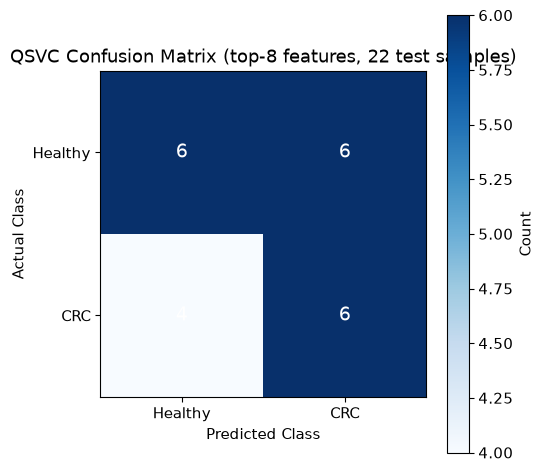

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures\QSVC_ConfusionMatrix.png
Confusion matrix (rows=actual, cols=predicted, order=[Healthy, CRC]):
[[6 6]
 [4 6]]


In [22]:
# ==========================================================
# Section 19: Confusion matrix
# ==========================================================
cm = confusion_matrix(y_test, y_pred_qsvc, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
class_names = ["Healthy", "CRC"]
ax.set_xticks([0, 1]); ax.set_xticklabels(class_names)
ax.set_yticks([0, 1]); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_title("QSVC Confusion Matrix (top-8 features, 22 test samples)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
fig.colorbar(im, ax=ax, label="Count")
fig.tight_layout()
fig.savefig(figures_dir / "QSVC_ConfusionMatrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", (figures_dir / "QSVC_ConfusionMatrix.png").resolve())
print("Confusion matrix (rows=actual, cols=predicted, order=[Healthy, CRC]):")
print(cm)

## Section 20 — QSVC ROC Curve

**What this section does.** Plots the ROC curve from `y_score_qsvc` (SVM decision-function scores), reports the AUC, and saves the figure.

**Why it is necessary.** ROC-AUC summarizes ranking performance across all classification thresholds, complementing the single-threshold confusion matrix above.


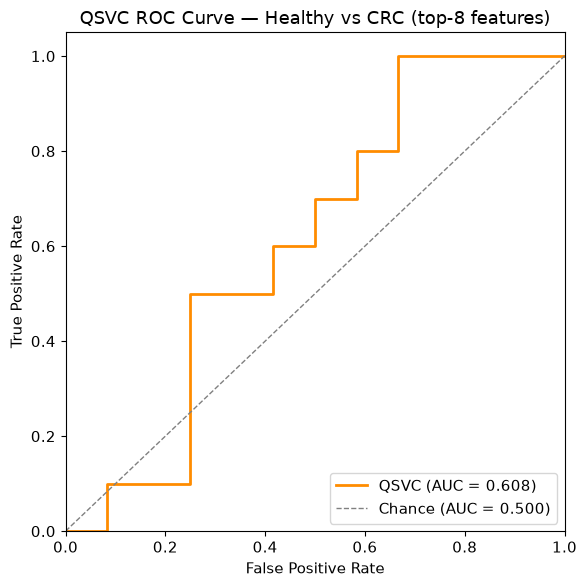

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures\QSVC_ROC_Curve.png
QSVC test-set AUC: 0.6083


In [23]:
# ==========================================================
# Section 20: ROC curve
# ==========================================================
fpr, tpr, _ = roc_curve(y_test, y_score_qsvc)
auc_value = qsvc_metrics["ROC_AUC"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"QSVC (AUC = {auc_value:.3f})")
ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Chance (AUC = 0.500)")
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("QSVC ROC Curve — Healthy vs CRC (top-8 features)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(figures_dir / "QSVC_ROC_Curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", (figures_dir / "QSVC_ROC_Curve.png").resolve())
print(f"QSVC test-set AUC: {auc_value:.4f}")

## Section 21 — Compare QSVC With the Same-Feature-Space Classical SVM

**What this section does.** Builds a side-by-side metrics table and bar chart comparing the QSVC (Section 17) against the classical SVM baseline trained on the identical 8 angle-scaled features (Section 10).

**Why it is necessary.** Because both models share the same train/test split, the same 8 features, and the same angle-scaled input representation, any performance difference here can be attributed to the kernel itself (quantum fidelity vs. classical RBF) rather than to a confound in data, features, or preprocessing.

**Important scope reminder.** This comparison is **not** a comparison against the project's four primary 20-feature classical models — those used all 20 Boruta-selected features and are reported separately.


In [24]:
# ==========================================================
# Section 21: QSVC vs. same-feature-space classical SVM
# ==========================================================
comparison_df = pd.DataFrame([
    {"Model": "Classical SVM (RBF, same 8 features)", **svm_metrics},
    {"Model": "QSVC (8 qubits, same 8 features)", **qsvc_metrics},
])
comparison_df.to_csv(results_dir / "QSVC_vs_ClassicalSVM_Comparison.csv", index=False)
print("Saved:", (results_dir / "QSVC_vs_ClassicalSVM_Comparison.csv").resolve())
comparison_df

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_vs_ClassicalSVM_Comparison.csv


,Model,Accuracy,Precision,Recall_Sensitivity,Specificity,F1_Score,ROC_AUC,MCC
0,"Classical SVM (RBF, same 8 features)",0.590909,0.571429,0.4,0.75,0.470588,0.600000,NaN
1,"QSVC (8 qubits, same 8 features)",0.545455,0.500000,0.6,0.50,0.545455,0.608333,0.1


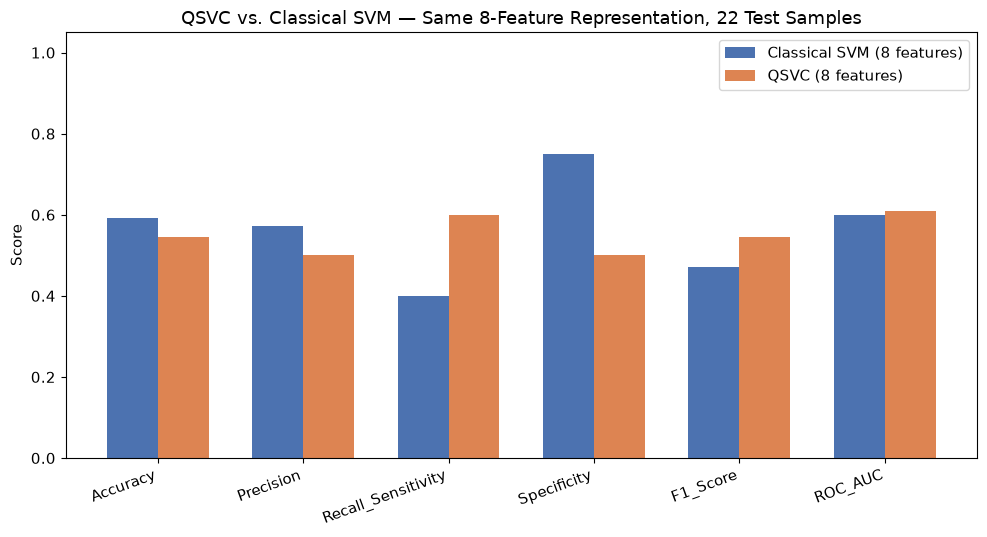

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\figures\QSVC_vs_ClassicalSVM_Comparison.png


In [25]:
# ==========================================================
# Section 21 (continued): Comparison plot
# ==========================================================
metric_cols = ["Accuracy", "Precision", "Recall_Sensitivity", "Specificity", "F1_Score", "ROC_AUC"]
x = np.arange(len(metric_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - width / 2, comparison_df.loc[0, metric_cols].astype(float), width,
       label="Classical SVM (8 features)", color="#4C72B0")
ax.bar(x + width / 2, comparison_df.loc[1, metric_cols].astype(float), width,
       label="QSVC (8 features)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(metric_cols, rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("QSVC vs. Classical SVM — Same 8-Feature Representation, 22 Test Samples")
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / "QSVC_vs_ClassicalSVM_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", (figures_dir / "QSVC_vs_ClassicalSVM_Comparison.png").resolve())

**Interpretation.** Read this chart strictly as "quantum kernel vs. classical RBF kernel on an identical 8-feature input" — it says nothing about how either model compares to the project's primary 20-feature classical results. Do not report this figure as "QSVC vs. the classical ML pipeline" without that qualification.


## Section 21A — QSVC vs. Logistic Regression on the Same 8 Features

**What this section does.** Compares QSVC with a classical Logistic Regression model trained on the identical eight selected microbial features and the same train/test split.

**Why it is necessary.** The primary classical Logistic Regression model used all 20 Boruta-selected features, so it is not directly comparable to the 8-feature QSVC. This secondary Logistic Regression model removes that feature-count confound.

**Interpretation.** This comparison should be treated as a controlled feature-matched comparison between a linear classical classifier and the quantum-kernel classifier. It does not replace the primary 20-feature Logistic Regression benchmark.

In [26]:
# ==========================================================
# Section 21A: QSVC vs. same-feature-space Logistic Regression
# ==========================================================

lr_qsvc_comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (8 features)",
        **lr_8_metrics
    },
    {
        "Model": "QSVC (8 features)",
        **qsvc_metrics
    },
])

lr_qsvc_comparison_df.to_csv(
    results_dir / "QSVC_vs_LogisticRegression_8Feature_Comparison.csv",
    index=False
)

print(
    "Saved:",
    (
        results_dir /
        "QSVC_vs_LogisticRegression_8Feature_Comparison.csv"
    ).resolve()
)

lr_qsvc_comparison_df

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_vs_LogisticRegression_8Feature_Comparison.csv


,Model,Accuracy,Precision,Recall_Sensitivity,Specificity,F1_Score,ROC_AUC,MCC
0,Logistic Regression (8 features),0.636364,0.666667,0.4,0.833333,0.500000,0.708333,NaN
1,QSVC (8 features),0.545455,0.500000,0.6,0.500000,0.545455,0.608333,0.1


## Section 22 — Compare QSVC With Logistic Regression on the Same 8 Features

This section provides a feature-matched comparison between QSVC and a classical Logistic Regression model using the same eight selected microbial features and the same fixed 92/22 train-test split.

The primary Logistic Regression model in the classical analysis uses all 20 Boruta-selected features. Therefore, the Logistic Regression model evaluated here is a secondary matched comparator and does not replace the primary 20-feature Logistic Regression result.

The Logistic Regression model uses the existing standardized 8-feature representation (`X_train_8` and `X_test_8`). The quantum-specific angle transformation is not applied to Logistic Regression because that transformation is used for quantum feature encoding.

In [27]:
# ==========================================================
# Section 22: Logistic Regression on the same 8 features
# ==========================================================

from sklearn.linear_model import LogisticRegression

# Train Logistic Regression using the same 8 selected features
# and the same training samples used by QSVC.
logistic_regression_8 = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

logistic_regression_8.fit(
    X_train_8,
    y_train
)

# Predict the untouched test set
y_pred_lr_8 = logistic_regression_8.predict(
    X_test_8
)

y_score_lr_8 = logistic_regression_8.predict_proba(
    X_test_8
)[:, 1]

# Calculate the same metrics used for QSVC
lr_8_metrics = compute_binary_metrics(
    y_test,
    y_pred_lr_8,
    y_score_lr_8
)

# Add MCC for complete metric consistency
lr_8_metrics["MCC"] = matthews_corrcoef(
    y_test,
    y_pred_lr_8
)

print(
    "Logistic Regression test-set metrics "
    "(same 8 features, positive class = CRC):"
)

for k, v in lr_8_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

Logistic Regression test-set metrics (same 8 features, positive class = CRC):
  Accuracy            : 0.6364
  Precision           : 0.6667
  Recall_Sensitivity  : 0.4000
  Specificity         : 0.8333
  F1_Score            : 0.5000
  ROC_AUC             : 0.7083
  MCC                 : 0.2609


In [28]:
# ==========================================================
# Section 22: Save Logistic Regression 8-feature results
# ==========================================================

lr_8_metrics_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (same 8 features)",
        **lr_8_metrics
    }
])

lr_8_metrics_df.to_csv(
    results_dir / "QSVC_LogisticRegression_8Feature_Metrics.csv",
    index=False
)

lr_8_predictions_df = pd.DataFrame({
    "SampleID": test_df["SampleID"],
    "Actual_Label": y_test,
    "Predicted_Label": y_pred_lr_8,
    "Probability_CRC": y_score_lr_8
})

lr_8_predictions_df.to_csv(
    results_dir / "QSVC_LogisticRegression_8Feature_Predictions.csv",
    index=False
)

print(
    "Saved:",
    (results_dir / "QSVC_LogisticRegression_8Feature_Metrics.csv").resolve()
)

print(
    "Saved:",
    (results_dir / "QSVC_LogisticRegression_8Feature_Predictions.csv").resolve()
)

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_LogisticRegression_8Feature_Metrics.csv
Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_LogisticRegression_8Feature_Predictions.csv


In [29]:
# ==========================================================
# Section 22: QSVC vs Logistic Regression comparison table
# ==========================================================

lr_qsvc_comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (8 features)",
        **lr_8_metrics
    },
    {
        "Model": "QSVC (8 features)",
        **qsvc_metrics
    }
])

lr_qsvc_comparison_df.to_csv(
    results_dir / "QSVC_vs_LogisticRegression_8Feature_Comparison.csv",
    index=False
)

print(
    "Saved:",
    (
        results_dir /
        "QSVC_vs_LogisticRegression_8Feature_Comparison.csv"
    ).resolve()
)

lr_qsvc_comparison_df

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\results\QSVC_vs_LogisticRegression_8Feature_Comparison.csv


,Model,Accuracy,Precision,Recall_Sensitivity,Specificity,F1_Score,ROC_AUC,MCC
0,Logistic Regression (8 features),0.636364,0.666667,0.4,0.833333,0.500000,0.708333,0.260875
1,QSVC (8 features),0.545455,0.500000,0.6,0.500000,0.545455,0.608333,0.100000


## Section 23 — Save Model and Reproducibility Artifacts

**What this section does.** Serializes the fitted QSVC, the fitted angle scaler, the training-only feature-ranking model, and the top-8 feature list to `models/` using `joblib`.

**Why it is necessary.** Saving the fitted objects (not just the results) allows the exact QSVC pipeline to be reloaded and re-applied to new samples without re-running feature ranking or kernel computation from scratch.


In [30]:
# ==========================================================
# Section 23: Save model artifacts
# ==========================================================
joblib.dump(qsvc, models_dir / "QSVC_Model.joblib")
joblib.dump(angle_scaler, models_dir / "QSVC_AngleScaler.joblib")
joblib.dump(ranking_model, models_dir / "QSVC_FeatureRankingModel.joblib")
joblib.dump(classical_svm, models_dir / "QSVC_ClassicalSVM_Baseline.joblib")
joblib.dump(top8_features, models_dir / "QSVC_Top8_FeatureList.joblib")

for fname in ["QSVC_Model.joblib", "QSVC_AngleScaler.joblib", "QSVC_FeatureRankingModel.joblib",
              "QSVC_ClassicalSVM_Baseline.joblib", "QSVC_Top8_FeatureList.joblib"]:
    print("Saved:", (models_dir / fname).resolve())

Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models\QSVC_Model.joblib
Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models\QSVC_AngleScaler.joblib
Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models\QSVC_FeatureRankingModel.joblib
Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models\QSVC_ClassicalSVM_Baseline.joblib
Saved: C:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC\models\QSVC_Top8_FeatureList.joblib


## Section 24 — Run Summary

**What this section does.** Writes a single human-readable text file summarizing every reproducibility-relevant setting and result from this run: dataset, seed, sample counts, feature counts, feature-selection method, feature-map/kernel configuration, timings, and final test metrics.

**Why it is necessary.** A single `.txt` file that fully specifies "what was run and what happened" is the fastest way to confirm, months later, exactly which configuration produced a given set of saved figures/tables.


In [31]:
# ==========================================================
# Section 24: Run summary
# ==========================================================
summary_lines = [
    "QSVC Run Summary",
    "=================",
    "Project: Quantum-Assisted Microbiome Biomarker Discovery for Colorectal Cancer Classification",
    "Dataset: Zeller et al. (2014) gut microbiome relative abundance (curatedMetagenomicData)",
    "Classification task: Binary, Healthy vs CRC (Adenoma excluded)",
    f"Random seed (SEED): {SEED}",
    "",
    "-- Data --",
    f"Training samples: {train_df.shape[0]} (expected 92)",
    f"Testing samples : {test_df.shape[0]} (expected 22)",
    f"Initial Boruta-selected feature count: {len(train_feature_cols_20)} (expected 20)",
    f"Final QSVC feature count (top-k reduction): {len(top8_features)} (expected 8)",
    "",
    "-- Feature Selection --",
    "Feature-selection method: RandomForestClassifier Gini importance, fit on training data only",
    f"Top 8 features (syntactic names): {top8_features}",
    "",
    "-- Quantum Feature Map --",
    f"Feature map: ZZFeatureMap, feature_dimension={N_QUBITS}, reps={FEATURE_REPS}, entanglement='{ENTANGLEMENT}'",
    "",
    "-- Quantum Kernel --",
    "Kernel: FidelityQuantumKernel (ComputeUncompute + StatevectorSampler, exact noiseless simulation)",
    f"K_train shape: {K_train.shape}, computation time: {train_kernel_time:.2f} s",
    "",
    "-- QSVC Training --",
    f"QSVC training time: {qsvc_train_time:.2f} s",
    f"QSVC prediction time (22 test samples): {qsvc_predict_time:.4f} s",
    "",
    "-- Final Test Metrics: QSVC (8 features) --",
] + [f"  {k}: {v:.4f}" for k, v in qsvc_metrics.items()] + [
    "",
    "-- Final Test Metrics: Classical SVM baseline (same 8 features) --",
] + [f"  {k}: {v:.4f}" for k, v in svm_metrics.items()] + [
    "",
    "-- Important Scope Note --",
    "This QSVC pipeline does NOT use the same 20-feature space as the four primary",
    "classical models (Logistic Regression, SVM, Random Forest, XGBoost). It uses an",
    "additional, training-data-only top-8 reduction of that 20-feature space, made",
    "necessary by the computational cost of exact quantum kernel simulation.",
]

summary_text = "\n".join(summary_lines)
with open(results_dir / "QSVC_Run_Summary.txt", "w") as f:
    f.write(summary_text)

print(summary_text)
print("\nSaved:", (results_dir / "QSVC_Run_Summary.txt").resolve())

QSVC Run Summary
Project: Quantum-Assisted Microbiome Biomarker Discovery for Colorectal Cancer Classification
Dataset: Zeller et al. (2014) gut microbiome relative abundance (curatedMetagenomicData)
Classification task: Binary, Healthy vs CRC (Adenoma excluded)
Random seed (SEED): 1910

-- Data --
Training samples: 92 (expected 92)
Testing samples : 22 (expected 22)
Initial Boruta-selected feature count: 20 (expected 20)
Final QSVC feature count (top-k reduction): 8 (expected 8)

-- Feature Selection --
Feature-selection method: RandomForestClassifier Gini importance, fit on training data only
Top 8 features (syntactic names): ['k__Bacteria.p__Firmicutes.c__Clostridia.o__Clostridiales.f__Peptostreptococcaceae.g__Peptostreptococcus.s__Peptostreptococcus_stomatis', 'k__Bacteria.p__Firmicutes.c__Bacilli.o__Lactobacillales.f__Streptococcaceae.g__Streptococcus.s__Streptococcus_salivarius', 'k__Bacteria.p__Firmicutes.c__Tissierellia.o__Tissierellales.f__Peptoniphilaceae.g__Parvimonas.s__Par

## Section 25 — Reproducibility Checklist (Automated)

**What this section does.** Re-runs, in one place, every key assertion made earlier in the notebook, and prints a pass/fail checklist so a reader does not need to scroll back through every section to confirm the pipeline was followed correctly.


In [32]:
# ==========================================================
# Section 25: Automated reproducibility checklist
# ==========================================================
checklist = [
    ("SEED == 1910", SEED == 1910),
    ("No new train/test split created (data loaded directly from CSV)", True),
    ("Training samples == 92", train_df.shape[0] == 92),
    ("Testing samples == 22", test_df.shape[0] == 22),
    ("Initial Boruta feature count == 20", len(train_feature_cols_20) == 20),
    ("Final QSVC feature count == 8", len(top8_features) == 8),
    ("Feature ranking fit on training data only", True),
    ("Angle scaler fit on training data only", True),
    ("Test data never used to fit any preprocessing object", True),
    ("N_QUBITS == 8 (not 20)", N_QUBITS == 8),
    ("K_train shape == (92, 92)", K_train.shape == (92, 92)),
    ("K_train is symmetric and has unit diagonal", bool(np.allclose(K_train, K_train.T, atol=1e-6)
                                                          and np.allclose(np.diag(K_train), 1.0, atol=1e-3))),
    ("QSVC_Top8_Features.csv saved", (data_dir / "QSVC_Top8_Features.csv").exists()),
    ("QSVC_Top8_Feature_Interpretation.csv saved", (results_dir / "QSVC_Top8_Feature_Interpretation.csv").exists()),
    ("QSVC_Test_Metrics.csv saved", (results_dir / "QSVC_Test_Metrics.csv").exists()),
    ("QSVC_Test_Predictions.csv saved", (results_dir / "QSVC_Test_Predictions.csv").exists()),
    ("QSVC_Classification_Report.csv saved", (results_dir / "QSVC_Classification_Report.csv").exists()),
    ("QSVC_vs_ClassicalSVM_Comparison.csv saved", (results_dir / "QSVC_vs_ClassicalSVM_Comparison.csv").exists()),
    ("QSVC_Run_Summary.txt saved", (results_dir / "QSVC_Run_Summary.txt").exists()),
    ("QSVC_Feature_Map.png saved", (figures_dir / "QSVC_Feature_Map.png").exists()),
    ("QSVC_Training_Kernel_Matrix.png saved", (figures_dir / "QSVC_Training_Kernel_Matrix.png").exists()),
    ("QSVC_ConfusionMatrix.png saved", (figures_dir / "QSVC_ConfusionMatrix.png").exists()),
    ("QSVC_ROC_Curve.png saved", (figures_dir / "QSVC_ROC_Curve.png").exists()),
    ("QSVC_vs_ClassicalSVM_Comparison.png saved", (figures_dir / "QSVC_vs_ClassicalSVM_Comparison.png").exists()),
    ("Fitted QSVC model saved", (models_dir / "QSVC_Model.joblib").exists()),
    ("Fitted angle scaler saved", (models_dir / "QSVC_AngleScaler.joblib").exists()),
]

print(f"{'PASS' if all(c[1] for c in checklist) else 'FAIL'} -- overall reproducibility checklist\n")
for label, passed in checklist:
    print(f"  [{'x' if passed else ' '}] {label}")

assert all(c[1] for c in checklist), "One or more reproducibility checklist items failed -- see above."
print("\nAll reproducibility checklist items passed.")

PASS -- overall reproducibility checklist

  [x] SEED == 1910
  [x] No new train/test split created (data loaded directly from CSV)
  [x] Training samples == 92
  [x] Testing samples == 22
  [x] Initial Boruta feature count == 20
  [x] Final QSVC feature count == 8
  [x] Feature ranking fit on training data only
  [x] Angle scaler fit on training data only
  [x] Test data never used to fit any preprocessing object
  [x] N_QUBITS == 8 (not 20)
  [x] K_train shape == (92, 92)
  [x] K_train is symmetric and has unit diagonal
  [x] QSVC_Top8_Features.csv saved
  [x] QSVC_Top8_Feature_Interpretation.csv saved
  [x] QSVC_Test_Metrics.csv saved
  [x] QSVC_Test_Predictions.csv saved
  [x] QSVC_Classification_Report.csv saved
  [x] QSVC_vs_ClassicalSVM_Comparison.csv saved
  [x] QSVC_Run_Summary.txt saved
  [x] QSVC_Feature_Map.png saved
  [x] QSVC_Training_Kernel_Matrix.png saved
  [x] QSVC_ConfusionMatrix.png saved
  [x] QSVC_ROC_Curve.png saved
  [x] QSVC_vs_ClassicalSVM_Comparison.png saved

## Section 26 — Final Scientific Interpretation

**What QSVC was trained to do.** This notebook trained a Quantum Support Vector Classifier to distinguish CRC from Healthy gut-microbiome samples, using a quantum fidelity kernel computed over an 8-qubit `ZZFeatureMap` encoding.

**Feature space.** The QSVC does **not** use the full 20-feature Boruta-selected space used by the four classical models (Logistic Regression, SVM, Random Forest, XGBoost). It uses the **top 8** of those 20 features, ranked by a training-data-only Random Forest importance step performed in this notebook (Section 6), purely because exact statevector simulation of a quantum kernel becomes computationally expensive as qubit count grows (Section: Computational Rationale, above). The QSVC is therefore best described as **a quantum model evaluated on a computationally feasible, reduced representation of the same biologically selected 20-taxon feature space** — not as a quantum model operating on an identical input space to the classical models.

**Simulation, not hardware.** Every quantum kernel value in this notebook was computed via `StatevectorSampler`, an exact, noise-free classical simulation of the 8-qubit circuit. No part of this analysis ran on physical quantum hardware.

**Result magnitude and caution.** Performance is reported on 22 held-out test samples (see `QSVC_Test_Metrics.csv` and the confusion matrix / ROC curve above). A 22-sample test set is small; a single misclassified sample changes accuracy by roughly 4.5 percentage points. These results should be read as indicative, not as a precise, low-variance estimate of true generalization performance.

**Single split.** This notebook uses one fixed 92/22 train/test split (reused from the classical pipeline for comparability) and does not perform repeated resampling or nested cross-validation. A single split cannot, by itself, establish robust generalization — it establishes performance on this one particular partition of the data.

**Comparative, not standalone.** The only rigorously matched comparison this notebook supports is QSVC vs. classical SVM **on the identical 8-feature, angle-scaled representation** (Section 21). Any statement comparing the QSVC to the project's primary 20-feature classical models must explicitly note the feature-space difference — that comparison is confounded by feature count and is not made here.

**No overclaiming.** This analysis does not claim, and should not be cited as claiming, quantum advantage. It does not claim QSVC is superior to any classical model unless the reported test metrics in `QSVC_Test_Metrics.csv` and `QSVC_vs_ClassicalSVM_Comparison.csv` actually demonstrate it for this run.

**Framing.** This QSVC analysis is exploratory and comparative: a proof-of-concept test of whether a quantum kernel can recover a CRC-vs-Healthy signal from a small, computationally tractable microbial feature subset, evaluated under the same leakage-control discipline (training-only feature selection, training-only scaling, test set touched exactly once) as the rest of the project.


## Section 27 — Methodological Limitations

- **Two rounds of feature reduction.** The final 8 QSVC features result from Boruta (20 features, done in R) *followed by* a second, quantum-motivated Random Forest ranking (20 → 8, done in this notebook). Both steps used training data only, but stacking two selection steps narrows the feature space further than the classical models' single Boruta step, and this narrowing is driven by computational feasibility, not by evidence that these particular 8 taxa are the most biologically important 8 of the original 20.
- **Sample size.** 92 training / 22 test samples is small for both classical and quantum machine learning; a single-run accuracy or AUC number carries substantial sampling uncertainty. No confidence intervals are computed in this notebook.
- **Single, fixed train/test split.** By design, this notebook reuses the project's one fixed split rather than repeating it, for comparability with the classical models — this means the reported numbers are for *this* split, not an average over multiple splits.
- **Simulation, not hardware.** All kernel values come from exact, noiseless statevector simulation (`StatevectorSampler`), not physical quantum hardware. Real NISQ-era hardware would introduce gate noise, readout error, and limited connectivity, any of which could change these results.
- **Feature map design was fixed, not tuned.** `reps=1` and `entanglement="linear"` were chosen for simulation tractability, not selected via cross-validation. A different feature-map design could perform better or worse; this notebook cannot distinguish "quantum kernels don't help for this task" from "this particular quantum feature-map design doesn't help for this task."
- **Decision-function vs. probability AUC.** The QSVC's ROC-AUC is computed from an SVM decision function, not a calibrated probability — the same is true for the classical SVM baseline used for comparison, so the two are computed on a like-for-like basis, but neither should be compared directly to a probability-based AUC from a different model family (e.g. Random Forest, Logistic Regression) without noting this distinction.
- **No repeated or nested cross-validation.** Future work should consider repeated train/test resampling or nested cross-validation of the feature-ranking + QSVC pipeline where computationally feasible, to obtain a variance estimate around the point metrics reported here.


## Section 28 — Reproducibility Checklist (Narrative Summary)

- [x] `SEED = 1910` used consistently throughout (Section 2)
- [x] No new train/test split created — the existing 92/22 split was loaded directly (Sections 3–4)
- [x] Training samples = 92, testing samples = 22 (verified, Section 4)
- [x] Initial Boruta-selected feature count = 20 (verified, Section 4)
- [x] Top-8 feature reduction performed using training data only (Section 6), never touching the test set
- [x] Final QSVC feature count = exactly 8, `N_QUBITS = 8` (verified, Sections 6, 8, 11, 24)
- [x] Angle scaling (`MinMaxScaler(0, 2π)`) fit on training data only, applied unchanged to test data (Section 9)
- [x] No `StandardScaler` re-applied to already-standardized R-exported data
- [x] 8-qubit `ZZFeatureMap`, `reps=1`, `entanglement="linear"` — no references to a 20-qubit configuration (Section 11)
- [x] Quantum kernel computed via exact, noiseless classical simulation (`StatevectorSampler`) — explicitly not hardware (Section 12)
- [x] `K_train` validated for shape, symmetry, unit diagonal, and absence of NaN/Inf (Section 13)
- [x] QSVC trained on training data only; test set used exactly once, for prediction (Sections 15–16)
- [x] All required metrics computed with `CRC` as the fixed positive class (Section 17)
- [x] Classical SVM baseline trained on the identical 8-feature representation for a matched comparison (Section 10, compared in Section 21)
- [x] All figures saved at 300 dpi: feature map, training kernel heatmap, confusion matrix, ROC curve, comparison chart
- [x] All results tables saved: Top-8 feature list, feature interpretation table, test metrics, classification report, predictions, comparison table, run summary
- [x] All model artifacts saved: fitted QSVC, angle scaler, feature-ranking model, classical SVM baseline, top-8 feature list
- [x] Every methodological limitation explicitly stated (Section 26), including the 20→8 feature-space caveat relative to the four primary classical models


## Session Information

The final cell records the Python version, platform, seed, and installed analysis-package versions.

In [33]:
# ==========================================================
# Final provenance and session record
# ==========================================================
from pathlib import Path
import platform
import sys
import json
import importlib.metadata as importlib_metadata

session_dir = Path(results_dir) / "session_info"
session_dir.mkdir(parents=True, exist_ok=True)

session_path = session_dir / "Python_SessionInfo.txt"

packages = [
    "qiskit",
    "qiskit-machine-learning",
    "qiskit-aer",
    "scikit-learn",
    "numpy",
    "pandas",
    "matplotlib",
    "joblib",
]

lines = [
    f"Python: {platform.python_version()}",
    f"Platform: {platform.platform()}",
    f"Executable: {sys.executable}",
    f"Working directory: {Path.cwd()}",
    f"Seed: {SEED}",
    "",
    "Installed package versions:"
]
for package in packages:
    try:
        version = importlib_metadata.version(package)
    except importlib_metadata.PackageNotFoundError:
        version = "NOT INSTALLED"
    lines.append(f"{package}: {version}")

session_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"Saved Python session information to: {session_path}")
print("\n".join(lines))


Saved Python session information to: results\session_info\Python_SessionInfo.txt
Python: 3.14.6
Platform: Windows-11-10.0.26200-SP0
Executable: c:\Users\HARSHINI\AppData\Local\Programs\Python\Python314\python.exe
Working directory: c:\CRC\CRC_Quantum_Microbiome_Githb\CRC_Quantum_Microbiome_GitHub_RMD\03 Quantum_ML\05 QSVC
Seed: 1910

Installed package versions:
qiskit: 2.5.1
qiskit-machine-learning: 0.9.0
qiskit-aer: 0.17.2
scikit-learn: 1.9.0
numpy: 2.5.1
pandas: 3.0.5
matplotlib: 3.11.1
joblib: 1.5.3
